# TASK 1

## Insturctions:
Discuss floor space price, height and land value gradients, and the land use allo-
cation in Figure 10 from Ahlfeldt & Barr (2022). Use the codes in the AB2022
toolkit (https://github.com/Ahlfeldt/AB2022-toolkit) to introduce a 20
floor height limit and discuss the general equilibrium effects with reference to
the mechanisms of the model. Experiment with the effects of the height limit
under varying values of other parameter values. Under what conditions is the
effect of a height limit particularly large?

In [28]:
# Set up for plotting
# Params for clean and minimalistic plots

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    #'figure.figsize': (6*2, 2*4.5),
    'font.size': 16.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

from pathlib import Path

PLOT_ROOT = Path.cwd() / "Plots"

## Recreation

The code below runs the basic model use in Fig 10 in the Paper. Note the populaion is fixed to 1.000.000

In [29]:
import numpy as np
import sys 

# Add the directory to the path
sys.path.append("Ports/Python/")

# Import using the filename (no .py)
from ab2022_model import AB2022Model


# Set up the parameters like in table 1 under figure 10
params = {
    'theta_C': 0.5, # 
    'theta_R': 0.55, #
    'omega_C': 0.03, #
    'omega_R': 0.07, #
    'beta_C': 0.03, #
    'a_bar_C': 2.0, #
    'a_bar_R': 1.0, #
    'tau_C': 0.01, #
    'tau_R': 0.005, #
    'c_C': 1.4, #
    'c_R': 1.4, #   
    'r_a': 30.0, #
    'S_bar_C': 999.0, # set to not binding
    'S_bar_R': 999.0, # set to not binidng
    # alpha values from Stata code
    'alpha_C': 0.85, # 1- alpha_c = 0.15
    'alpha_R': 0.67, # 1 - alpha_r= 0.33
    'beta_R': 0.0 # not specified
}

model = AB2022Model(params)

L_fixed = 1000000
L_eq = L_fixed
print("Running Baseline Model...")
y_eq = model.find_wage(L=L_fixed, y_guess=2.5)
res = model.solver(L=L_fixed, y=y_eq)

#L_eq, y_eq, res = model.find_eq(L_guess=1000000, y_guess=2.5)

# Calculate Radii
# CBD Radius (x0): boundary where commercial use ends (U=1)
x = res['x']
U = res['U']

cbd_mask = (U == 1) & (x >= 0)  
if np.any(cbd_mask):
    # The CBD ends where U is no longer 1. 
    # In this symmetric model, we look at positive x.
    cbd_radius = np.max(x[cbd_mask])
else:
    cbd_radius = 0.0
    
urban_mask = (U != 3) & (x >= 0)
if np.any(urban_mask):
    urban_radius = np.max(x[urban_mask])
else:
    urban_radius = 0.0
    
print("-" * 30)
print(f"Results:")
print(f"Total Employment (L): {L_eq:,.2f}")
print(f"Equilibrium Wage (y): {y_eq:.4f}")
print(f"CBD Radius (x0):      {cbd_radius:.2f} km")
print(f"Urban Radius (x1):    {urban_radius:.2f} km")
print("-" * 30)

Running Baseline Model...
------------------------------
Results:
Total Employment (L): 1,000,000.00
Equilibrium Wage (y): 2.2733
CBD Radius (x0):      5.05 km
Urban Radius (x1):    34.09 km
------------------------------


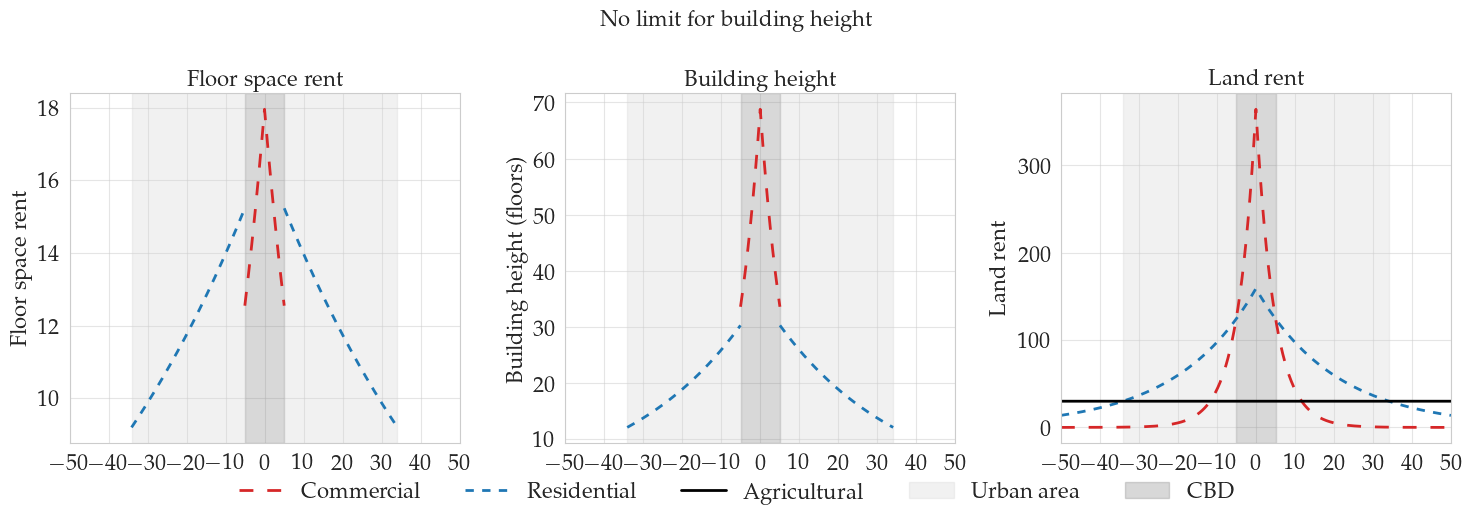

In [30]:
import matplotlib.pyplot as plt

x = res['x']
U = res['U']

# Identify CBD and Urban Area boundaries
cbd_mask = (U == 1)
urban_mask = (U == 2)
cbd_max = x[cbd_mask].max() if cbd_mask.any() else 0
urban_max = x[urban_mask].max() if urban_mask.any() else 0

# Colors and line styles matching the paper
c_comm = 'tab:red'
c_res = 'tab:blue'
c_agri = 'black'

# To show discontinuities in Floor Space Rent and Building Height, 
# we mask the arrays so we only plot the values for the "winning" land use.
p_C_realized = np.where(U == 1, res['p_C_bid'], np.nan)
p_R_realized = np.where(U == 2, res['p_R_bid'], np.nan)
S_C_realized = np.where(U == 1, res['S_star_C'], np.nan)
S_R_realized = np.where(U == 2, res['S_star_R'], np.nan)

# Create Subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Floor space rent
ax = axes[0]
ax.plot(x, p_C_realized, color=c_comm, linestyle=(0, (5, 5)), linewidth=2, label='Commercial')
ax.plot(x, p_R_realized, color=c_res, linestyle=(0, (3, 3)), linewidth=2, label='Residential')
ax.set_title('Floor space rent')
ax.set_ylabel('Floor space rent')
#ax.set_ylim(0, 20)

# Panel 2: Building height
ax = axes[1]
ax.plot(x, S_C_realized, color=c_comm, linestyle=(0, (5, 5)), linewidth=2, label='Commercial')
ax.plot(x, S_R_realized, color=c_res, linestyle=(0, (3, 3)), linewidth=2, label='Residential')
ax.set_title('Building height')
ax.set_ylabel('Building height (floors)')
#ax.set_ylim(0, 80)

# Panel 3: Land rent
ax = axes[2]
# For land rent, plot the full bid rent curves to show where they intersect
ax.plot(x, res['r_C'], color=c_comm, linestyle=(0, (5, 5)), linewidth=2, label='Commercial')
ax.plot(x, res['r_R'], color=c_res, linestyle=(0, (3, 3)), linewidth=2, label='Residential')
ax.plot(x, np.full_like(x, params['r_a']), color=c_agri, linestyle='-', linewidth=2, label='Agricultural')
ax.set_title('Land rent')
ax.set_ylabel('Land rent')
#ax.set_ylim(0, 400)

# Apply common formatting to all axes
for ax in axes:
    ax.set_xlim(-50, 50)
    # Highlight regions
    ax.axvspan(-cbd_max, cbd_max, color='gray', alpha=0.3, label='CBD')
    ax.axvspan(-urban_max, -cbd_max, color='lightgray', alpha=0.3, label='Urban area')
    ax.axvspan(cbd_max, urban_max, color='lightgray', alpha=0.3)
    ax.grid(True, alpha=0.5)
    ax.set_xticks(np.arange(-50, 60, 10))

# Custom Legend at the bottom
handles, labels = axes[2].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
order = ['Commercial', 'Residential', 'Agricultural', 'Urban area', 'CBD']
ordered_handles = [by_label[k] for k in order if k in by_label]
ordered_labels = [k for k in order if k in by_label]
fig.suptitle("No limit for building height",fontsize=16)
fig.legend(ordered_handles, ordered_labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
plt.savefig(PLOT_ROOT / "task_1_1.png", bbox_inches='tight', dpi=300)
plt.show()

We can see that the *floorspace price* increasses the close we get to the CBD the price even eclipses the price at the outer CBD, which is likely to the increased height of the buildings. Due to a jump of the building heigt at the CBD, while the Land Rent is equal at the border of the CBD.

The *Building height* is also increases towards the city-center, moreover the CBD has strcitly higher buildings. 

The *Land Rent* in the CBD is the highest for Buiness Districts, but generally increases towards the city center.

## Introdcution of Building height caps

Running Baseline Model...
------------------------------
Results:
Total Employment (L): 1,000,000.00
Equilibrium Wage (y): 2.2346
CBD Radius (x0):      7.97 km
Urban Radius (x1):    30.65 km
------------------------------


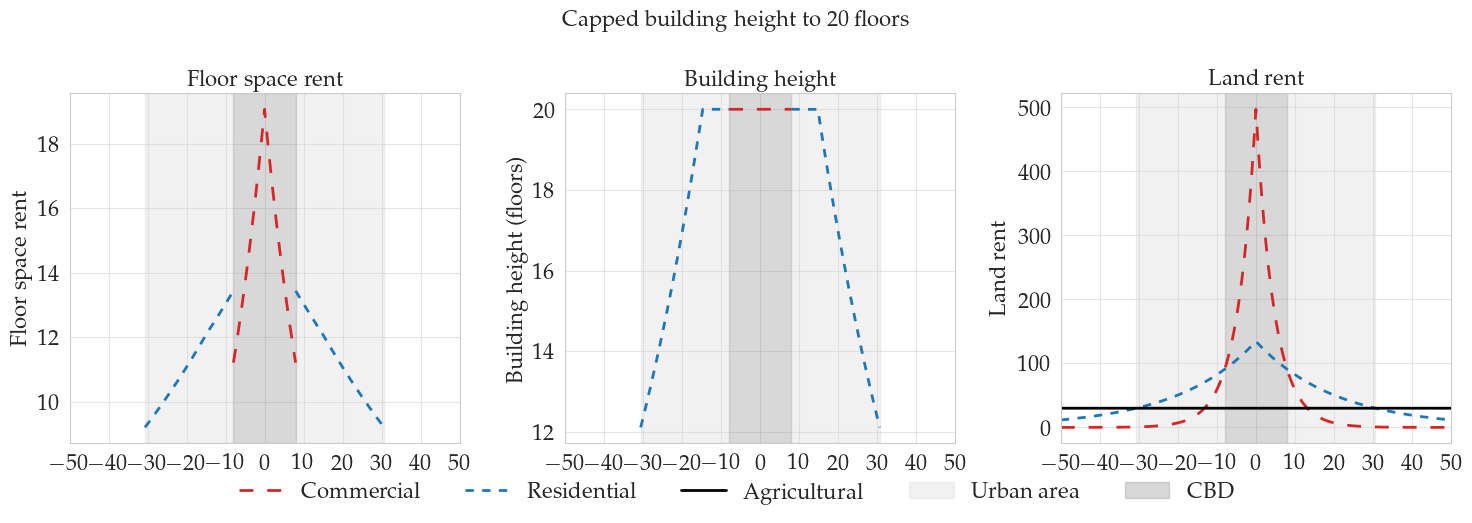

In [31]:
import numpy as np
import sys 

# Add the directory to the path
sys.path.append("Ports/Python/")

from ab2022_model import AB2022Model


# Set up the parameters like in table 1 under figure 10
params = {
    'theta_C': 0.5, # 
    'theta_R': 0.55, #
    'omega_C': 0.03, #
    'omega_R': 0.07, #
    'beta_C': 0.03, #
    'a_bar_C': 2.0, #
    'a_bar_R': 1.0, #
    'tau_C': 0.01, #
    'tau_R': 0.005, #
    'c_C': 1.4, #
    'c_R': 1.4, #   
    'r_a': 30.0, #
    'S_bar_C': 20.0, # set to 20 floors
    'S_bar_R': 20.0, # set to 20 floors
    # alpha values from Stata code
    'alpha_C': 0.85, # 1- alpha_c = 0.15
    'alpha_R': 0.67, # 1 - alpha_r= 0.33
    'beta_R': 0.0 # not specified
}

model = AB2022Model(params)

L_fixed = 1000000
print("Running Baseline Model...")
y_eq = model.find_wage(L=L_fixed, y_guess=2.5)
L_eq = L_fixed
res = model.solver(L=L_fixed, y=y_eq)

#L_eq, y_eq, res = model.find_eq(L_guess=1000000, y_guess=2.5)

# Calculate Radii
# CBD Radius (x0): boundary where commercial use ends (U=1)
x = res['x']
U = res['U']

cbd_mask = (U == 1) & (x >= 0)
if np.any(cbd_mask):
    # The CBD ends where U is no longer 1. 
    # In this symmetric model, we look at positive x.
    cbd_radius = np.max(x[cbd_mask])
else:
    cbd_radius = 0.0
    
urban_mask = (U != 3) & (x >= 0)
if np.any(urban_mask):
    urban_radius = np.max(x[urban_mask])
else:
    urban_radius = 0.0
    
print("-" * 30)
print(f"Results:")
print(f"Total Employment (L): {L_eq:,.2f}")
print(f"Equilibrium Wage (y): {y_eq:.4f}")
print(f"CBD Radius (x0):      {cbd_radius:.2f} km")
print(f"Urban Radius (x1):    {urban_radius:.2f} km")
print("-" * 30)

import matplotlib.pyplot as plt

x = res['x']
U = res['U']

# Identify CBD and Urban Area boundaries
cbd_mask = (U == 1)
urban_mask = (U == 2)
cbd_max = x[cbd_mask].max() if cbd_mask.any() else 0
urban_max = x[urban_mask].max() if urban_mask.any() else 0

# Colors and line styles matching the paper
c_comm = 'tab:red'
c_res = 'tab:blue'
c_agri = 'black'

# To show discontinuities in Floor Space Rent and Building Height, 
# we mask the arrays so we only plot the values for the "winning" land use.
p_C_realized = np.where(U == 1, res['p_C_bid'], np.nan)
p_R_realized = np.where(U == 2, res['p_R_bid'], np.nan)
S_C_realized = np.where(U == 1, res['S_C'], np.nan)
S_R_realized = np.where(U == 2, res['S_R'], np.nan)

# Create Subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Floor space rent
ax = axes[0]
ax.plot(x, p_C_realized, color=c_comm, linestyle=(0, (5, 5)), linewidth=2, label='Commercial')
ax.plot(x, p_R_realized, color=c_res, linestyle=(0, (3, 3)), linewidth=2, label='Residential')
ax.set_title('Floor space rent')
ax.set_ylabel('Floor space rent')
#ax.set_ylim(0, 20)

# Panel 2: Building height
ax = axes[1]
ax.plot(x, S_C_realized, color=c_comm, linestyle=(0, (5, 5)), linewidth=2, label='Commercial')
ax.plot(x, S_R_realized, color=c_res, linestyle=(0, (3, 3)), linewidth=2, label='Residential')
ax.set_title('Building height')
ax.set_ylabel('Building height (floors)')
#ax.set_ylim(0, 80)

# Panel 3: Land rent
ax = axes[2]
# For land rent, plot the full bid rent curves to show where they intersect
ax.plot(x, res['r_C'], color=c_comm, linestyle=(0, (5, 5)), linewidth=2, label='Commercial')
ax.plot(x, res['r_R'], color=c_res, linestyle=(0, (3, 3)), linewidth=2, label='Residential')
ax.plot(x, np.full_like(x, params['r_a']), color=c_agri, linestyle='-', linewidth=2, label='Agricultural')
ax.set_title('Land rent')
ax.set_ylabel('Land rent')
#ax.set_ylim(0, 400)

# Apply common formatting to all axes
for ax in axes:
    ax.set_xlim(-50, 50)
    # Highlight regions
    ax.axvspan(-cbd_max, cbd_max, color='gray', alpha=0.3, label='CBD')
    ax.axvspan(-urban_max, -cbd_max, color='lightgray', alpha=0.3, label='Urban area')
    ax.axvspan(cbd_max, urban_max, color='lightgray', alpha=0.3)
    ax.grid(True, alpha=0.5)
    ax.set_xticks(np.arange(-50, 60, 10))

# Custom Legend at the bottom
handles, labels = axes[2].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
order = ['Commercial', 'Residential', 'Agricultural', 'Urban area', 'CBD']
ordered_handles = [by_label[k] for k in order if k in by_label]
ordered_labels = [k for k in order if k in by_label]

fig.suptitle("Capped building height to 20 floors",fontsize=16)
fig.legend(ordered_handles, ordered_labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
plt.savefig(PLOT_ROOT / "task_1_2.png", bbox_inches='tight', dpi=300)
plt.show()

### Interpretation

The land rent for the buisness discrtrict generally increase in the CBD, however, the building height cannot adjust. So the CBD is wider ~8 km against ~5km preaviously. Moreover, due to the higher scarcity of floorspace the overall landrent increases. 

## Sensitivity analysis

In [32]:
import numpy as np
import pandas as pd
import sys

sys.path.append("Ports/Python/")
from ab2022_model import AB2022Model

def solve_L(params, L_guess=1_000_000, y_guess=2.5):
    m = AB2022Model(params)
    L, y, res = m.find_eq(L_guess, y_guess)
    return L, y

def run_avg_L(params, n_runs=10):
    vals = []
    for _ in range(n_runs):
        L, _ = solve_L(params)
        vals.append(L)
    return float(np.mean(vals))

def rel_change(new, old):
    return (new - old) / old if old > 0 else np.nan

# Baseline from model defaults
#base = AB2022Model().params.copy()
base = params
base['x_1_bar'] = 999.0

base["theta_C"] = 0.5
base["theta_R"] = 0.55
base["beta_C"] = 0.03
base['tau_R'] = 0.005

params_to_test = [
    "alpha_C", "alpha_R", "theta_C", "theta_R", "omega_C", "omega_R",
    "beta_C", "beta_R", "a_bar_C", "a_bar_R", "tau_C", "tau_R",
    "c_C", "c_R", "r_a", "x_1_bar"
]

rows = []
n_runs = 10
increase_factor = 1.10  # 10% increase

for pname in params_to_test:
    # No limit scenario
    p_no_base = base.copy()
    p_no_base["S_bar_C"] = 999.0
    p_no_base["S_bar_R"] = 999.0

    p_no_up = p_no_base.copy()
    p_no_up[pname] = p_no_up[pname] * increase_factor

    L_no_base_avg = run_avg_L(p_no_base, n_runs=n_runs)
    L_no_up_avg = run_avg_L(p_no_up, n_runs=n_runs)

    # Limit 20 scenario
    p_lim_base = base.copy()
    p_lim_base["S_bar_C"] = 20.0
    p_lim_base["S_bar_R"] = 20.0

    p_lim_up = p_lim_base.copy()
    p_lim_up[pname] = p_lim_up[pname] * increase_factor

    L_lim_base_avg = run_avg_L(p_lim_base, n_runs=n_runs)
    L_lim_up_avg = run_avg_L(p_lim_up, n_runs=n_runs)

    rc_no = rel_change(L_no_up_avg, L_no_base_avg)
    rc_lim = rel_change(L_lim_up_avg, L_lim_base_avg)

    rows.append({
        "parameter": pname,
        "avg_rel_change_L_no_limit": rc_no,
        "avg_rel_change_L_limit_20": rc_lim,
        "delta_of_avg_relative_changes": rc_lim - rc_no,
    })

out = pd.DataFrame(rows).sort_values("parameter")
display(out)



,parameter,avg_rel_change_L_no_limit,avg_rel_change_L_limit_20,delta_of_avg_relative_changes
8,a_bar_C,1.436112,0.603105,-0.833007
9,a_bar_R,1.434359,0.679358,-0.755001
0,alpha_C,6.327566,1.792068,-4.535498
1,alpha_R,5.051163,1.393971,-3.657193
6,beta_C,0.569724,0.261460,-0.308264
7,beta_R,0.000000,0.000000,0.000000
12,c_C,-0.097740,-0.021909,0.075832
13,c_R,-0.200660,-0.121566,0.079094
4,omega_C,0.020679,0.009465,-0.011214
5,omega_R,0.075453,0.038363,-0.037090


In [33]:
out_proc = out.copy()
# To percentage points
out_proc['avg_rel_change_L_no_limit'] = out_proc['avg_rel_change_L_no_limit'] * 100
out_proc['avg_rel_change_L_limit_20'] = out_proc['avg_rel_change_L_limit_20'] * 100 
out_proc['delta_of_avg_relative_changes'] = out_proc['delta_of_avg_relative_changes'] * 100
print(out_proc.to_latex(index=False, float_format="%.2f"))


\begin{tabular}{lrrr}
\toprule
parameter & avg_rel_change_L_no_limit & avg_rel_change_L_limit_20 & delta_of_avg_relative_changes \\
\midrule
a_bar_C & 143.61 & 60.31 & -83.30 \\
a_bar_R & 143.44 & 67.94 & -75.50 \\
alpha_C & 632.76 & 179.21 & -453.55 \\
alpha_R & 505.12 & 139.40 & -365.72 \\
beta_C & 56.97 & 26.15 & -30.83 \\
beta_R & 0.00 & 0.00 & 0.00 \\
c_C & -9.77 & -2.19 & 7.58 \\
c_R & -20.07 & -12.16 & 7.91 \\
omega_C & 2.07 & 0.95 & -1.12 \\
omega_R & 7.55 & 3.84 & -3.71 \\
r_a & -2.09 & -3.03 & -0.94 \\
tau_C & -2.14 & -3.05 & -0.91 \\
tau_R & -9.90 & -7.96 & 1.94 \\
theta_C & -21.32 & -3.79 & 17.54 \\
theta_R & -34.19 & -21.26 & 12.93 \\
x_1_bar & 0.00 & 0.00 & 0.00 \\
\bottomrule
\end{tabular}



# TASK 2

## Replication of Fig. 15
The Section in the Article goes as follows:

"[...] we solve our model for varying values of the height elasticity of construction cost $\{ \theta_C , \theta_R \}$. [...] we select a different value for the commercial height elasticity of construction cost, $\theta_C $, in each run and adjust the residential residential elasticity such that the difference between the commercial and residential elasticity conforms to the baseline, i.e., $ \theta_R = \theta_C − 0.005$. This way, we only change one parameter value at a time, which allows us to present the results in Fig. 15 using."

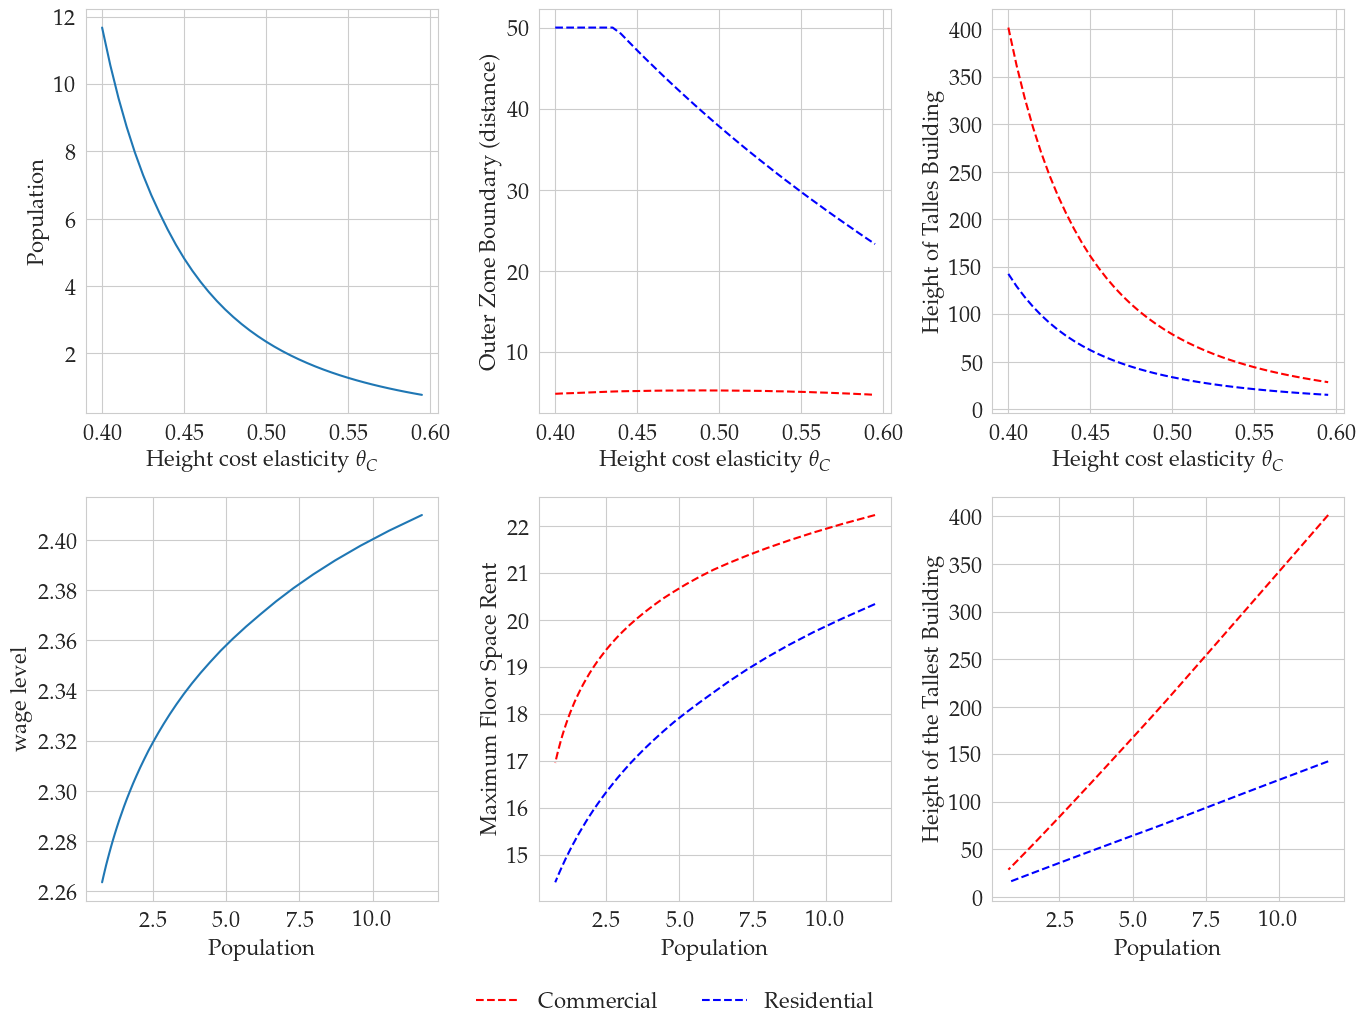

In [34]:
pops, wages = [],[] # Array for the resulting L and y
max_fls_rent_C,max_fls_rent_R = [],[] # arrays that save the max floor space rent
max_S_Cs, max_S_Rs = [],[] # arras saving the 
u_rad_s= [] # Array to save the urban rad
theta_list = []

from ab2022_jit import AB2022JITModel

params = {
    'theta_C': 0.5, # 
    'theta_R': 0.45, #
    'omega_C': 0.03, #
    'omega_R': 0.07, #
    'beta_C': 0.03, #
    'a_bar_C': 2.0, #
    'a_bar_R': 1.0, #
    'tau_C': 0.01, #
    'tau_R': 0.005, #
    'c_C': 1.4, #
    'c_R': 1.4, #   
    'r_a': 30.0, #
    'S_bar_C': 999.0, # No building heigh penalty
    'S_bar_R': 999.0, # No building heigh penalty
    # alpha values from Stata code
    'alpha_C': 0.85, # 1- alpha_c = 0.15
    'alpha_R': 0.67, # 1 - alpha_r= 0.33
    'beta_R': 0.0 # not specified
} # Parameters Finished

thetas = np.arange(0.4, 0.6, 0.005)

data = AB2022JITModel.run_parallel_sweep('theta_C', thetas, params)

import matplotlib.pyplot as plt

data['L'] = data['L']/1000000 # change to per million   

# Added sharey='row' to keep scales consistent within each row
fig, axs = plt.subplots(2, 3, figsize=(14, 10))

# --- ROW 0: Agglomeration Elasticity ---
label_x0 = r"Height cost elasticity $\theta_C$"

axs[0, 0].plot(data['param_values'], data['L'])
axs[0, 0].set_xlabel(label_x0)
axs[0, 0].set_ylabel("Population")

axs[0, 1].plot(data['param_values'], data['cbd_radius'], '--', color='red', label='Commercial')
axs[0, 1].plot(data['param_values'], data['urban_radius'], '--', color='blue', label='Residential')
axs[0, 1].set_xlabel(label_x0)
axs[0, 1].set_ylabel("Outer Zone Boundary (distance)")

axs[0, 2].plot(data['param_values'], data['max_S_C'], '--', color='red', label='Commercial')
axs[0, 2].plot(data['param_values'], data['max_S_R'], '--', color='blue', label='Residential')
axs[0, 2].set_xlabel(label_x0)
axs[0, 2].set_ylabel("Height of Talles Building")

# --- ROW 1: Population ---
label_x1 = "Population"

axs[1, 0].plot(data['L'], data['y'])
axs[1, 0].set_xlabel(label_x1)
axs[1, 0].set_ylabel("wage level")

# Fixed the duplicate labels and color logic here
axs[1, 1].plot(data['L'], data['max_p_C'], '--', color='red', label='Commercial')
axs[1, 1].plot(data['L'], data['max_p_R'], '--', color='blue', label='Residential')
axs[1, 1].set_ylabel("Maximum Floor Space Rent")
axs[1, 1].set_xlabel(label_x1)

axs[1, 2].plot(data['L'], data['max_S_C'], '--', color='red', label='Commercial')
axs[1, 2].plot(data['L'], data['max_S_R'], '--', color='blue', label='Residential')
axs[1, 2].set_xlabel(label_x1)
axs[1, 2].set_ylabel("Height of the Tallest Building")

# Collect unique legend items from all subplots
handles, labels = axs[0, 1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Create single legend at the bottom
fig.legend(by_label.values(), by_label.keys(), loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), frameon=False)

# Final layout polish
plt.tight_layout()
plt.savefig(PLOT_ROOT / "task_2_1.png", bbox_inches='tight', dpi=300)
plt.show()

In [35]:
data_to_save = {key: data[key].tolist() for key in data.keys()}

In [36]:
# Dump the dict: data, as json for later use
import json
with open(Path.cwd() / "Data" / "task_2_1_data.json", "w") as f:
    json.dump(data_to_save, f, indent=4)

In [37]:
pops, wages = [],[] # Array for the resulting L and y
max_fls_rent_C,max_fls_rent_R = [],[] # arrays that save the max floor space rent
max_S_Cs, max_S_Rs = [],[] # arras saving the 
u_rad_s= [] # Array to save the urban rad
theta_list = []

from ab2022_jit import AB2022JITModel

params = {
    'theta_C': 0.5, # 
    'theta_R': 0.45, #
    'omega_C': 0.03*1.1, #
    'omega_R': 0.07*1.1, #
    'beta_C': 0.03, #
    'a_bar_C': 2.0, #
    'a_bar_R': 1.0, #
    'tau_C': 0.01, #
    'tau_R': 0.005, #
    'c_C': 1.4, #
    'c_R': 1.4, #   
    'r_a': 30.0, #
    'S_bar_C': 999.0, # No building heigh penalty
    'S_bar_R': 999.0, # No building heigh penalty
    # alpha values from Stata code
    'alpha_C': 0.85, # 1- alpha_c = 0.15
    'alpha_R': 0.67, # 1 - alpha_r= 0.33
    'beta_R': 0.0 # not specified
} # Parameters Finished

thetas = np.arange(0.4, 0.6, 0.005)

data = AB2022JITModel.run_parallel_sweep('theta_C', thetas, params)
data_to_save = {key: data[key].tolist() for key in data.keys()}

with open(Path.cwd() / "Data" / "task_2_1_data_omega.json", "w") as f:
    json.dump(data_to_save, f, indent=4)